In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 

In [2]:
log_paths = glob.glob('../logs/exp1d/*/*/*.csv')

In [3]:
log_df = load_accuracy_log(log_paths)

100%|██████████| 12270/12270 [00:36<00:00, 338.10it/s]


aggregate result by select the smallest test_l2

In [4]:
log_agg_df = log_df.groupby(['model', 'dataset', 'coarse_level','resolution','residual'])['test_l2'].apply(np.min).reset_index()

#### trend on different residual type at same coarse level

In [5]:
# sub_df = log_agg_df[(log_agg_df.model == 'gt1d') & (log_agg_df.coarse_level == 0)]
# g = sns.catplot(data=sub_df, x='residual', y='test_l2', row='dataset', col='resolution', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
# g.set(yscale='log')

#### test relative L2 error on different residual type at same resolution

In [6]:
fno1d_df = log_agg_df[(log_agg_df.coarse_level == 0) & (log_agg_df.dataset=='burgers') & (log_agg_df.model == 'fno1d')]
fno1d_table = pd.pivot_table(fno1d_df, values='test_l2', index=['resolution'], columns=['residual'])
fno1d_table = fno1d_table.reindex(['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], axis=1)

lno1d_df = log_agg_df[(log_agg_df.coarse_level == 0) & (log_agg_df.dataset=='lnabs') & (log_agg_df.model == 'lno1d')]
lno1d_table = pd.pivot_table(lno1d_df, values='test_l2', index=['resolution'], columns=['residual'])
lno1d_table = lno1d_table.reindex(['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], axis=1)

ft1d_df = log_agg_df[(log_agg_df.coarse_level == 0) & (log_agg_df.dataset=='cosine') & (log_agg_df.model == 'ft1d')]
ft1d_table = pd.pivot_table(ft1d_df, values='test_l2', index=['resolution'], columns=['residual'])
ft1d_table = ft1d_table.reindex(['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], axis=1)

gt1d_df = log_agg_df[(log_agg_df.coarse_level == 0) & (log_agg_df.dataset=='cosine') & (log_agg_df.model == 'gt1d')]
gt1d_table = pd.pivot_table(gt1d_df, values='test_l2', index=['resolution'], columns=['residual'])
gt1d_table = gt1d_table.reindex(['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], axis=1)

In [7]:
lno1d_table.idxmin(axis=1)

resolution
512      ml4
1024     ml4
2048     ml4
4096     ml3
8192    null
dtype: object

#### trend on different residual type and coarse level at same resolution

In [8]:
# sub_df = log_agg_df[(log_agg_df.model == 'gt1d') & (log_agg_df.resolution == 2048)]
# g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', row='dataset', kind='point', col_order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
# g.set(yscale='log')

In [21]:
fno1d_df = log_agg_df[(log_agg_df.model == 'fno1d')]
fno1d_table = pd.pivot_table(fno1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])

<Axes: xlabel='coarse_level', ylabel='resolution-residual'>

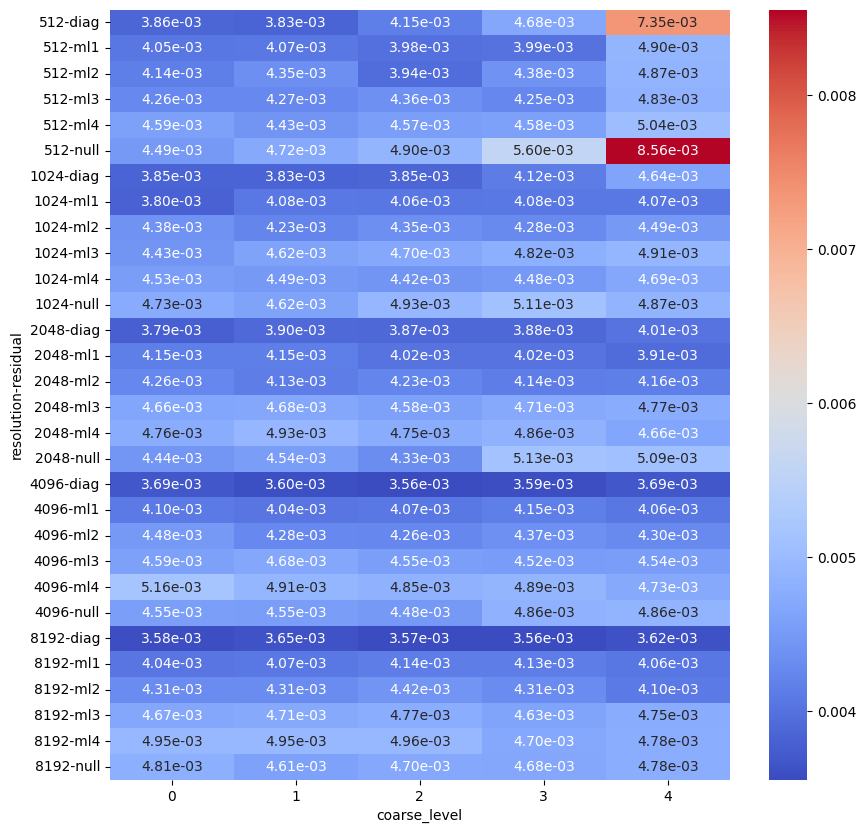

In [55]:
plt.figure(figsize=(10, 10))
sns.heatmap(fno1d_table['burgers'], annot=True,  fmt=".2e", cmap='coolwarm')#,  norm=LogNorm(fno1d_table['burgers'].min().min(), fno1d_table['burgers'].max().max()))

In [53]:
fno1d_table['burgers'].min().min()

0.0035561947338283

In [73]:
fno1d_df = log_agg_df[(log_agg_df.model == 'fno1d')]
fno1d_table = pd.pivot_table(fno1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
# fno1d_table = fno1d_table.reindex([0, 1, 2, 3, 4], axis=1)
# print(fno1d_table.idxmin(axis=1))

# lno1d_df = log_agg_df[(log_agg_df.dataset=='cosine') & (log_agg_df.model == 'lno1d')]
# lno1d_table = pd.pivot_table(lno1d_df, values='test_l2', index=['resolution', 'residual'], columns=['coarse_level'])
# lno1d_table = lno1d_table.reindex([0, 1, 2, 3, 4], axis=1)
# print(fno1d_table.idxmin(axis=1))

In [78]:
g = sns.catplot(data=fno1d_df, x='residual', y='coarse_level', col='dataset', row='resolution', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='test_l2')

KeyboardInterrupt: 

In [10]:
log_paths = glob.glob('../logs/exp2d/*/*/*.csv')
log_df = load_accuracy_log(log_paths)

100%|██████████| 4088/4088 [00:13<00:00, 314.01it/s]


In [11]:
log_agg_df = log_df.groupby(['model', 'dataset', 'coarse_level','resolution','residual'])['test_l2'].apply(np.min).reset_index()

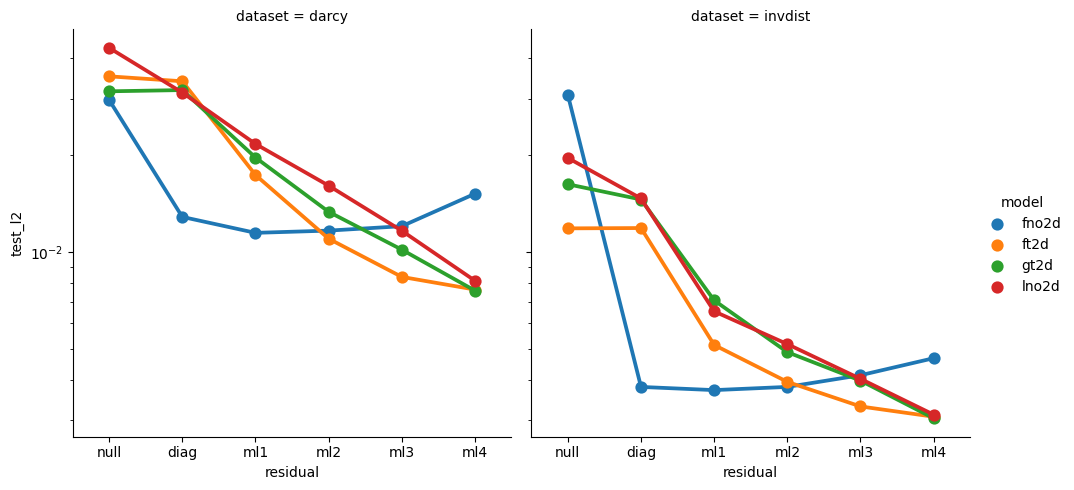

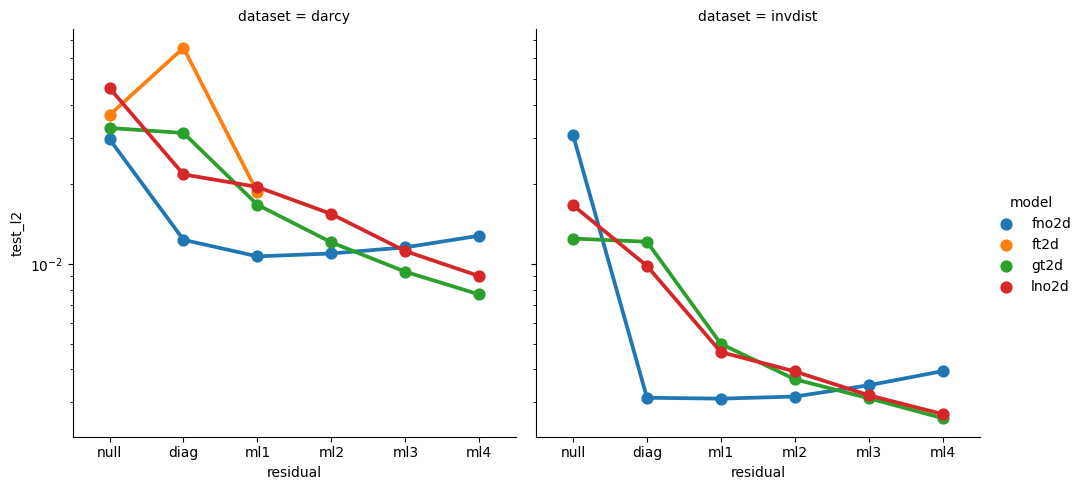

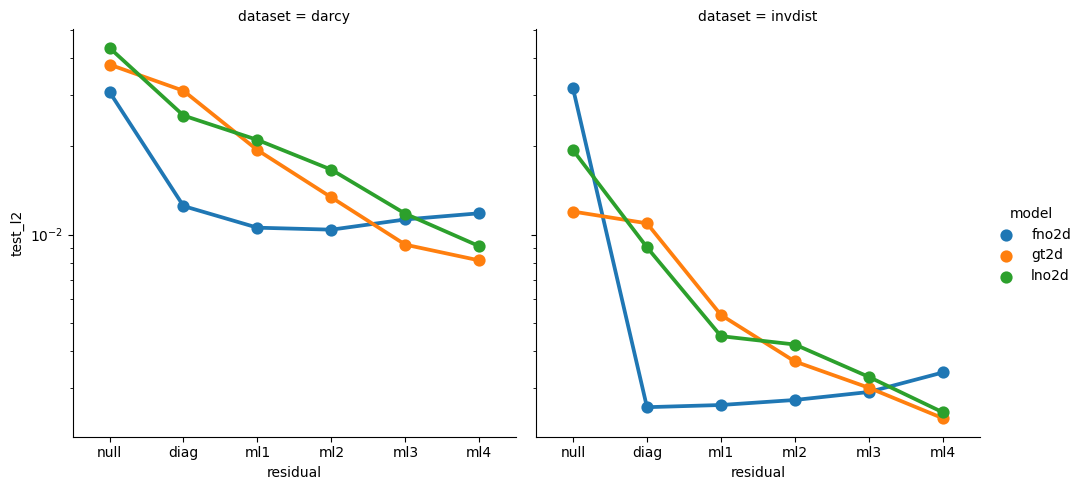

In [13]:
sub_df = log_agg_df[(log_agg_df.resolution == 85) & (log_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')

sub_df = log_agg_df[(log_agg_df.resolution == 106) & (log_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')

sub_df = log_agg_df[(log_agg_df.resolution == 141) & (log_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')

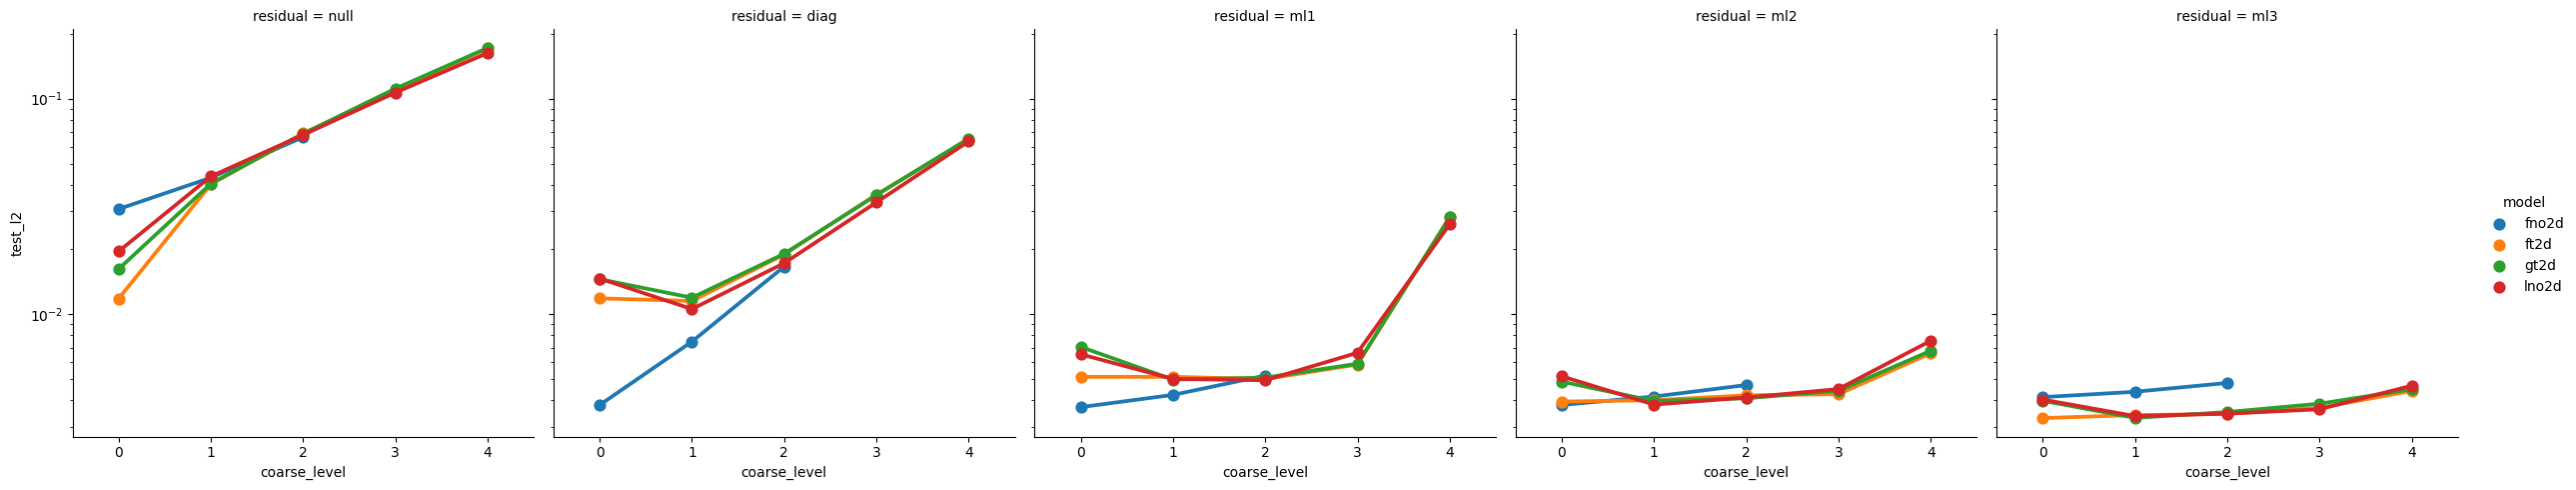

In [13]:
sub_df = log_agg_df[(log_agg_df.resolution == 85) & (log_agg_df.dataset == 'invdist')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='point', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3'], hue='model')
g.set(yscale='log')

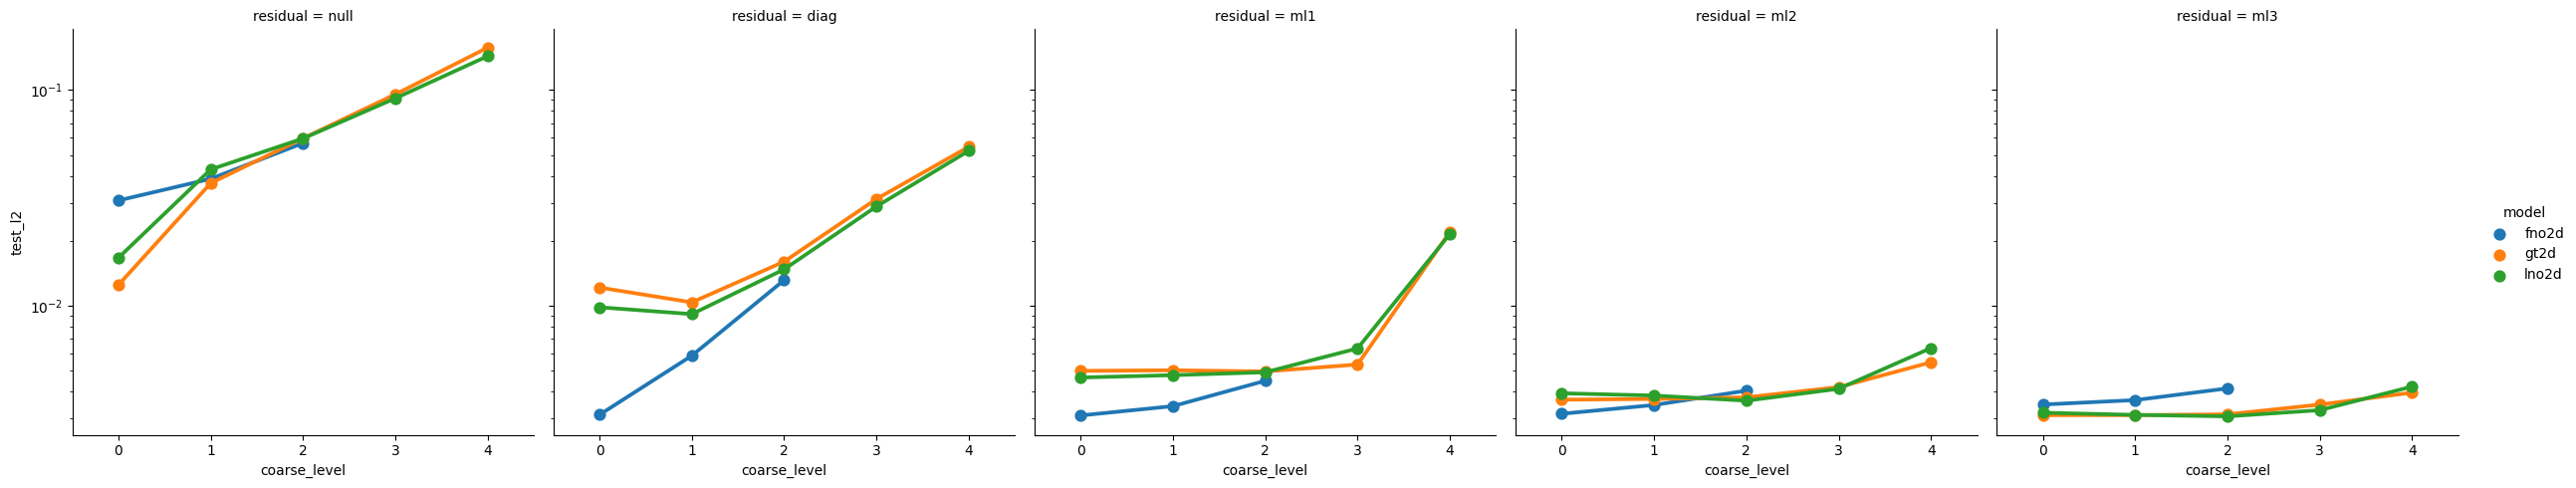

In [12]:
sub_df = log_agg_df[(log_agg_df.resolution == 106) & (log_agg_df.dataset == 'invdist')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='point', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3'], hue='model')
g.set(yscale='log')

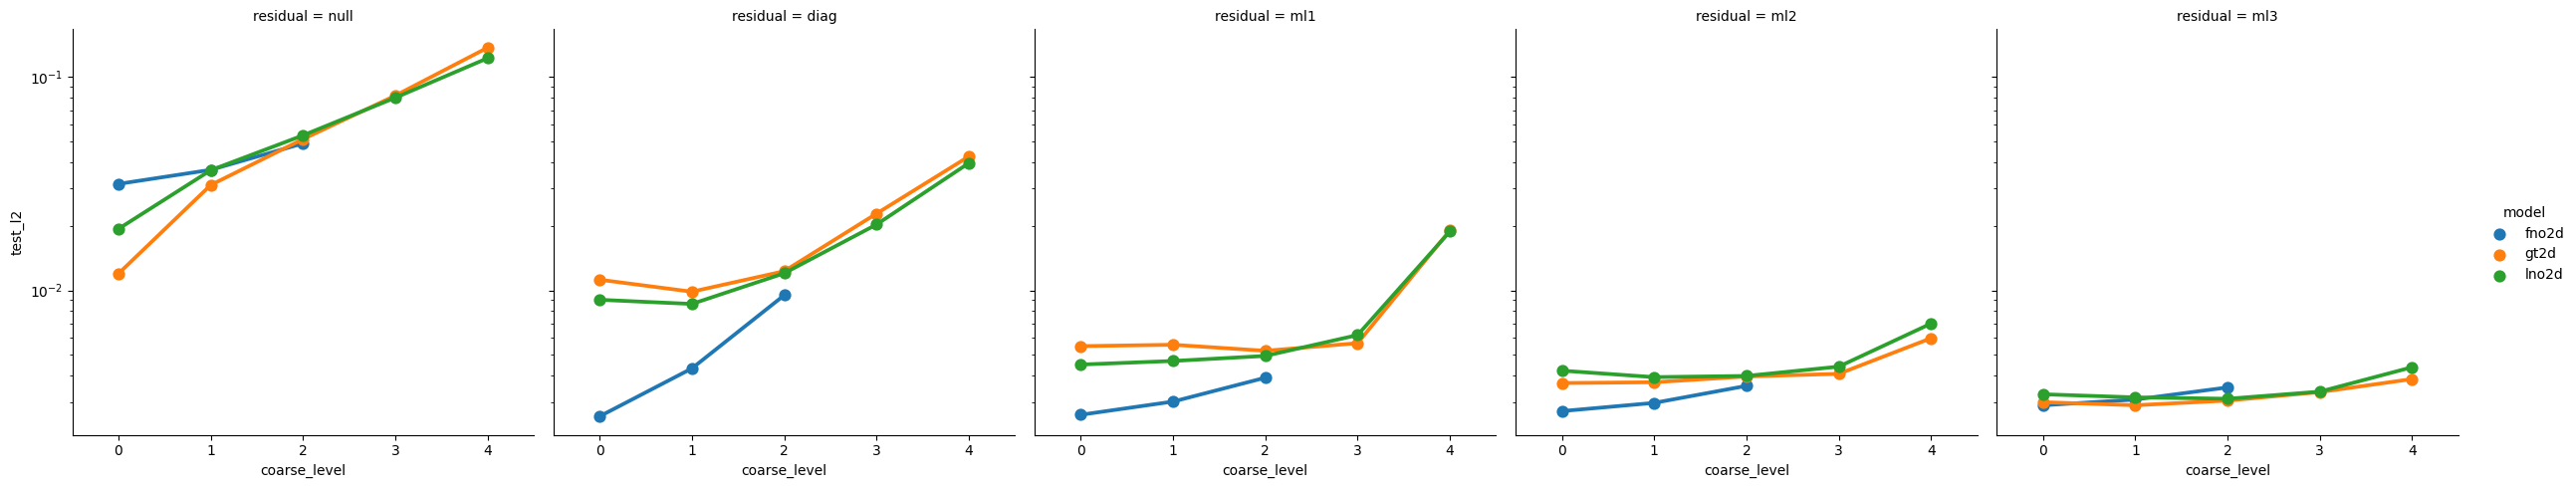

In [11]:
sub_df = log_agg_df[(log_agg_df.resolution == 141) & (log_agg_df.dataset == 'invdist')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='point', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3'], hue='model')
g.set(yscale='log')


In [10]:
# sub_df = log_df[(log_df.resolution == 512) & (log_df.dataset == 'poisson') & (log_df.model == 'gt1d')]
# g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='strip', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], hue='model')
# g.set(yscale='log')